# Sampler comparison figure

Generative PPL, DUEL PPL, Entropy, MAUVE vs NFE for the four block-sampling rules on OWT (BD3-LM L'=16).

All numbers are hard-coded below.
- Gen-PPL / Entropy / MAUVE: sampler runs (1000 samples each, filtered to entropy>=1.0), NFEs from generation mode.
- DUEL-PPL: `mode=duel_ppl` runs against `openwebtext-valid-1k`, NFEs are the canonical 128/256/512/1024.
- ELBO baseline: `mode=elbo_ppl` on the same validation set, val/ppl = 23.52.

The `k` column is the number of tokens unmasked simultaneously per step for the integer-k rules.
For `block_confidence_threshold`, `k` is the threshold value:
- Gen-mode thresholds: 0.045 / 0.08 / 0.16 / 1.0 -> NFE 131 / 278 / 518 / 921
- Eval-mode (DUEL) thresholds: 0.05 / 0.07 / 0.15 / 0.99 -> NFE 128 / 256 / 512 / 1024

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

In [32]:
# Gen-PPL sweep (sample_logs/), NFEs from generation mode.
# k: integer-k rules -> tokens unmasked per step; confidence_threshold -> threshold value.
gen_rows = [
    # block_greedy: k tokens per step
    ('block_greedy',               1,     1023, 16.45,  5.066, 0.2572),
    ('block_greedy',               2,     512,  128.17, 4.871, 0.0303),
    ('block_greedy',               4,     256,  355.89, 4.683, 0.0085),
    ('block_greedy',               8,     128,  536.13, 4.766, 0.0053),
    # block_left_to_right: k tokens per step
    ('block_left_to_right',        1,     1023, 17.02,  5.133, 0.2487),
    ('block_left_to_right',        2,     512,  182.40, 4.107, 0.0094),
    ('block_left_to_right',        4,     256,  316.36, 4.127, 0.0055),
    ('block_left_to_right',        8,     128,  519.04, 4.606, 0.0050),
    # block_probability_margin: k tokens per step
    ('block_probability_margin',   1,     1023, 18.41,  5.086, 0.2033),
    ('block_probability_margin',   2,     512,  110.46, 4.996, 0.0352),
    ('block_probability_margin',   4,     256,  371.31, 4.728, 0.0078),
    ('block_probability_margin',   8,     128,  531.06, 4.771, 0.0050),
    # block_confidence_threshold: k is the THRESHOLD (gen-mode values)
    # threshold 0.045 -> ~131 NFE, 0.08 -> ~278, 0.16 -> ~518, 1.0 -> ~921 (gen-mode ceiling)
    ('block_confidence_threshold', 0.045, 131,  757.70, 5.072, 0.0050),
    ('block_confidence_threshold', 0.08,  278,  515.20, 4.950, 0.0067),
    ('block_confidence_threshold', 0.16,  518,  189.07, 4.920, 0.0242),
    ('block_confidence_threshold', 1.0,   921,  16.69,  5.052, 0.2296),
]
gen_data = pd.DataFrame(gen_rows, columns=['strategy', 'k', 'nfe', 'gen_ppl', 'entropy', 'mauve'])
gen_data

,strategy,k,nfe,gen_ppl,entropy,mauve
0,block_greedy,1.000,1023,16.45,5.066,0.2572
1,block_greedy,2.000,512,128.17,4.871,0.0303
2,block_greedy,4.000,256,355.89,4.683,0.0085
3,block_greedy,8.000,128,536.13,4.766,0.0053
4,block_left_to_right,1.000,1023,17.02,5.133,0.2487
5,block_left_to_right,2.000,512,182.40,4.107,0.0094
6,block_left_to_right,4.000,256,316.36,4.127,0.0055
7,block_left_to_right,8.000,128,519.04,4.606,0.0050
8,block_probability_margin,1.000,1023,18.41,5.086,0.2033
9,block_probability_margin,2.000,512,110.46,4.996,0.0352


In [33]:
# DUEL-PPL sweep (logs/), NFEs canonical from eval mode.
# k: integer-k rules -> tokens unmasked per step; confidence_threshold -> threshold value.
duel_rows = [
    ('block_greedy',               1,    1024, 22.04),
    ('block_greedy',               2,    512,  34.74),
    ('block_greedy',               4,    256,  67.15),
    ('block_greedy',               8,    128,  165.48),
    ('block_left_to_right',        1,    1024, 21.46),
    ('block_left_to_right',        2,    512,  44.51),
    ('block_left_to_right',        4,    256,  109.00),
    ('block_left_to_right',        8,    128,  240.27),
    ('block_probability_margin',   1,    1024, 22.35),
    ('block_probability_margin',   2,    512,  32.33),
    ('block_probability_margin',   4,    256,  57.66),
    ('block_probability_margin',   8,    128,  141.31),
    # block_confidence_threshold: k is the THRESHOLD (eval-mode values)
    # threshold 0.05 -> 128 NFE, 0.07 -> 256, 0.15 -> 512, 0.99 -> 1024
    ('block_confidence_threshold', 0.05, 128,  227.77),
    ('block_confidence_threshold', 0.07, 256,  116.95),
    ('block_confidence_threshold', 0.15, 512,  43.45),
    ('block_confidence_threshold', 0.99, 1024, 22.04),
]
duel_data = pd.DataFrame(duel_rows, columns=['strategy', 'k', 'nfe', 'duel_ppl'])

# ELBO baseline (mode=elbo_ppl on openwebtext-valid-1k)
ELBO_PPL = 23.52
duel_data

,strategy,k,nfe,duel_ppl
0,block_greedy,1.00,1024,22.04
1,block_greedy,2.00,512,34.74
2,block_greedy,4.00,256,67.15
3,block_greedy,8.00,128,165.48
4,block_left_to_right,1.00,1024,21.46
5,block_left_to_right,2.00,512,44.51
6,block_left_to_right,4.00,256,109.00
7,block_left_to_right,8.00,128,240.27
8,block_probability_margin,1.00,1024,22.35
9,block_probability_margin,2.00,512,32.33


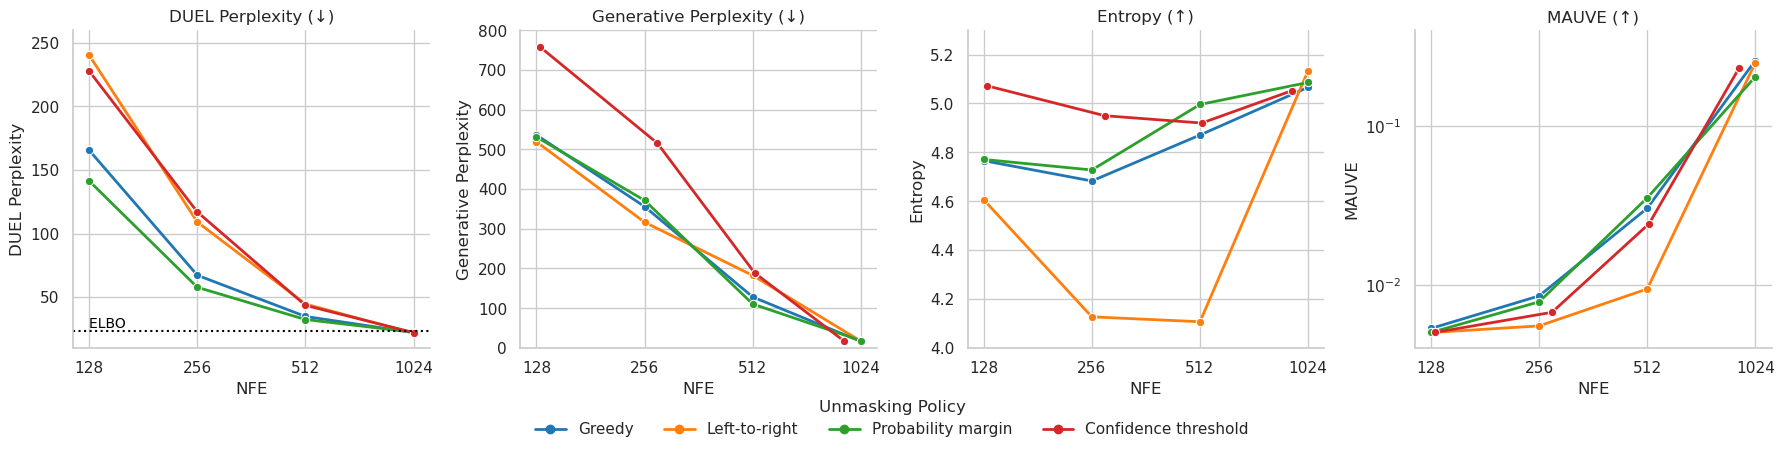

In [34]:
sns.set_theme(style='whitegrid', context='notebook')

STRATEGY_ORDER = ['block_greedy', 'block_left_to_right', 'block_probability_margin', 'block_confidence_threshold']
STRATEGY_LABELS = {
    'block_greedy': 'Greedy',
    'block_left_to_right': 'Left-to-right',
    'block_probability_margin': 'Probability margin',
    'block_confidence_threshold': 'Confidence threshold',
}
palette = dict(zip(STRATEGY_ORDER, sns.color_palette('tab10', n_colors=len(STRATEGY_ORDER))))

# Long-format frame for relplot. Each (strategy, k, nfe, metric, value).
# DUEL-PPL uses its own NFE column (canonical 128/256/512/1024) since the
# threshold rule maps to slightly different NFEs in gen vs eval mode.
combined = pd.concat([
    gen_data.melt(id_vars=['strategy', 'k', 'nfe'],
                  value_vars=['gen_ppl', 'entropy', 'mauve'],
                  var_name='metric', value_name='value'),
    duel_data.melt(id_vars=['strategy', 'k', 'nfe'],
                   value_vars=['duel_ppl'],
                   var_name='metric', value_name='value'),
], ignore_index=True)

# DUEL Perplexity first, then Generative Perplexity, then Entropy, then MAUVE
METRIC_ORDER = ['duel_ppl', 'gen_ppl', 'entropy', 'mauve']
METRIC_LABELS = {
    'duel_ppl': 'DUEL Perplexity',
    'gen_ppl':  'Generative Perplexity',
    'entropy':  'Entropy',
    'mauve':    'MAUVE',
}
METRIC_DIRECTION = {  # arrow shown in subplot title
    'duel_ppl': '↓',
    'gen_ppl':  '↓',
    'entropy':  '↑',
    'mauve':    '↑',
}
YLIMS = {
    'gen_ppl':  (0, 800),
    'duel_ppl': (10, 260),
    'entropy':  (4.0, 5.3),
    'mauve':    (0.004, 0.4),
}
LOG_Y = {'mauve'}


def style_axis(ax, metric):
    """Apply log x-axis, plain tick labels, ylim, and proper labels for one panel."""
    ax.set_xscale('log')
    ax.set_xticks([128, 256, 512, 1024])
    xfmt = ScalarFormatter()
    xfmt.set_scientific(False)
    ax.xaxis.set_major_formatter(xfmt)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel('NFE')
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(f'{METRIC_LABELS[metric]} ({METRIC_DIRECTION[metric]})')
    ax.set_ylim(YLIMS[metric])
    if metric in LOG_Y:
        ax.set_yscale('log')
    else:
        yfmt = ScalarFormatter(useOffset=False)
        yfmt.set_scientific(False)
        ax.yaxis.set_major_formatter(yfmt)


def policy_legend_handles():
    return [
        Line2D([0], [0], color=palette[s], marker='o', linewidth=2, label=STRATEGY_LABELS[s])
        for s in STRATEGY_ORDER
    ]


# --- Appendix figure: 4 panels in one row -----------------------------------
g = sns.relplot(
    data=combined, x='nfe', y='value',
    hue='strategy', hue_order=STRATEGY_ORDER, palette=palette,
    col='metric', col_order=METRIC_ORDER,
    kind='line', marker='o', linewidth=2,
    facet_kws={'sharey': False, 'sharex': True},
    height=4.5, aspect=1.0, legend=False,
)

for metric, ax in g.axes_dict.items():
    style_axis(ax, metric)

# ELBO baseline on the DUEL Perplexity panel, annotated in-axes
duel_ax = g.axes_dict['duel_ppl']
duel_ax.axhline(ELBO_PPL, linestyle=':', color='black', linewidth=1.5)
duel_ax.text(128, ELBO_PPL, 'ELBO ', va='bottom', ha='left',
             fontsize=10, color='black')

g.figure.legend(handles=policy_legend_handles(), loc='lower center',
                ncol=len(STRATEGY_ORDER), bbox_to_anchor=(0.5, -0.02),
                frameon=False, title='Unmasking Policy')
g.figure.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Main-paper figure: DUEL PPL and Generative PPL only, stacked vertically

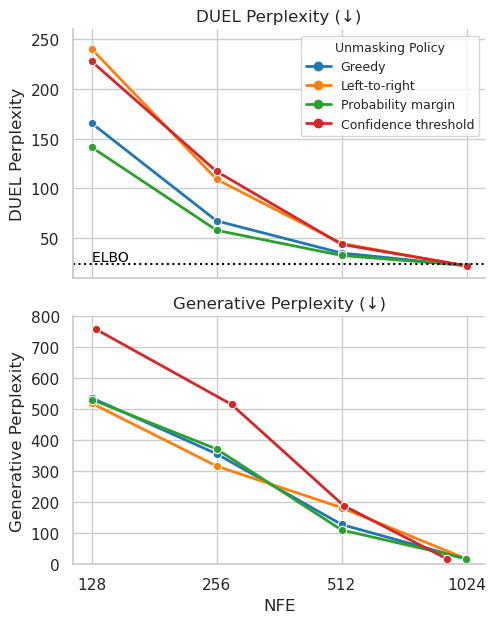

In [35]:
# Smaller figure for the main paper: only DUEL PPL and Gen PPL, stacked vertically.
MAIN_METRICS = ['duel_ppl', 'gen_ppl']
main_data = combined[combined['metric'].isin(MAIN_METRICS)]

g_main = sns.relplot(
    data=main_data, x='nfe', y='value',
    hue='strategy', hue_order=STRATEGY_ORDER, palette=palette,
    row='metric', row_order=MAIN_METRICS,
    kind='line', marker='o', linewidth=2,
    facet_kws={'sharey': False, 'sharex': True},
    height=3.2, aspect=1.6, legend=False,
)

for metric, ax in g_main.axes_dict.items():
    style_axis(ax, metric)

duel_ax = g_main.axes_dict['duel_ppl']
duel_ax.axhline(ELBO_PPL, linestyle=':', color='black', linewidth=1.5)
duel_ax.text(128, ELBO_PPL, 'ELBO ', va='bottom', ha='left',
             fontsize=10, color='black')

# Legend in the upper-right corner of the top (DUEL PPL) subplot
duel_ax.legend(handles=policy_legend_handles(), loc='upper right',
               title='Unmasking Policy', frameon=True, fontsize=9, title_fontsize=9)

g_main.figure.tight_layout()
plt.show()